# FigTemp_n2_grid — the $n=2$ population vs Balmer-photoionization equilibrium

Test of the envelope's defining opacity: if the $n=2$ population is set by recombination balanced
against Balmer-continuum photoionization, then $n_2^{\rm pred}=n_e n_p\,\alpha_2(T_e)/\Gamma_{\rm BaC}$,
with the **atomic** $\alpha_2=0.32\,\alpha_B(T_e)$ (not fitted) and $\Gamma_{\rm BaC}$ from the actual MC field.
Top row = marginally-unbound `dilute_redd` (m2.5/m5/m10/m20); bottom row = photon-tired $f=0.94$ ($\Gamma_0=1.21$).

In [1]:
import os, glob
import numpy as np, pandas as pd
import wind_scales                 # one definition of r_sph (Mdot-dependent)
import matplotlib.pyplot as plt

# ================= config: edit here to point at your data / output =================
# (self-contained per notebook for now; lift this block into a shared repro_paths.py
#  once the final matrix_pow + custom-band reruns exist and dirs are unified.)
DATA_ROOT = os.environ.get("SIROCCO_REPRO_DATA", "/scratch/gpfs/nk6352/sirocco_runs")
FIG_DIR   = os.path.abspath("../figures")           # where this notebook writes its PDF/PNG
# NOTE: runs use matrix_pow ionization; photon sampling is user_bands (5 bands,
#   0.05-100 eV) for the mu family and wide for the ptf family. Photon-tired family = ptf_*
#   (f=0.94 tiring fraction, Gamma_0=1.2128 Owocki+2017 winds), superseding the legacy
#   g1.38 pt_* family; all four ptf runs completed & health-checked 2026-08-13.
#   ptf m10/m15 unconverged cells lie beyond the H recombination front (t_e collapse in
#   decoupled neutral gas; converged inside), so SPECTRA come from the *_trunc_speconly
#   extraction reruns where noted, while wind-structure tables read the parent dirs.
RUN_DIRS = {"m2.5": "repro/mu_m2.5", "m5": "repro/mu_m5",
                   "m10": "repro/mu_m10", "m15": "repro/mu_m15",
                   "pt_m2.5": "repro/ptf_m2.5", "pt_m5": "repro/ptf_m5",
                   "pt_m10": "repro/ptf_m10", "pt_m15": "repro/ptf_m15_n300"}   # m15 = 300-cell run (steady resolved front; n100 oscillation was a grid artifact)
def run_path(k): return os.path.join(DATA_ROOT, RUN_DIRS[k])
os.makedirs(FIG_DIR, exist_ok=True)

# ---- manuscript style ----
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'serif', 'mathtext.fontset': 'dejavuserif',
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 10,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})
# ====================================================================================

# ---- physical constants (cgs) ----
C=2.998e10; H=6.6261e-27; KB=1.3807e-16; A_RAD=7.5657e-15
NU_BALMER=8.2249e14            # Balmer edge, 3646 A
NU_LYMAN =4*NU_BALMER          # Lyman edge, 912 A

def load_jnu(rd):
    x=pd.read_csv(sorted(glob.glob(f'{rd}/outflow.xspec.all*.txt'))[0],sep=r'\s+')
    cols=[c for c in x.columns if c!='Freq.' and c.startswith('F')]
    return x['Freq.'].values, x[cols].values        # freq[Nf], jnu[Nf,Ncell]

import breaks   # one definition of the break radii, shared by all three figures
trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz   # renamed in numpy 2.0; works under both pins

def edge_break_radius(freq, jnu, r, nu_edge, *_, **__):
    """Radius where the CONTINUUM across the edge first drops by breaks.BREAK_THRESHOLD.

    Delegates to analysis/breaks.py so FigOpticalDepth, FigHeatCool and
    FigTemp_n2_grid all mark the same thing. Each side of the edge is fitted with
    the exact diluted-blackbody basis and extrapolated to the edge, so a smooth
    spectrum returns 1 at any colour temperature -- the old J(0.97nu)/J(1.03nu)
    ratio charged the continuum slope to the break and reported a spurious break
    in cool input spectra (a 7000 K blackbody scored 3.2 at the Lyman edge).
    Legacy jt / jt_base arguments are accepted and ignored."""
    return breaks.break_radius(freq, jnu, r, nu_edge)

# (label, run key in RUN_DIRS) -- marginally-unbound dilute_redd grid
RUNS=[('m2.5','m2.5'),('m5','m5'),('m10','m10'),('m15','m15')]

In [2]:
NU2=NU_BALMER; SIG2=1.386e-17; X_H=0.71; M_P=1.6726e-24; ME=9.109e-28; EV=1.602e-12
def n2_saha(Te,ne,npr):
    chi2=13.6/4*EV; g2=8.0
    Lam3=(H**2/(2*np.pi*ME*KB*Te))**1.5
    return ne*npr*(g2/2.0)*Lam3*np.exp(np.minimum(chi2/(KB*Te),700.))
def aB(T): return 2.59e-13*(T/1e4)**-0.833
def simGamma2(J,fr,Nc,thr,sig0,e0):
    s=fr>=thr; nu=fr[s]; sig=sig0*(e0/nu)**3; out=np.zeros(Nc); nn=min(Nc,J.shape[1])
    out[:nn]=trapz((4*np.pi*J[:,s]/(H*nu))*sig,nu,axis=1); return out

def n2_phieq(run_dir):
    m=pd.read_csv(f'{run_dir}/outflow.master.txt',sep=r'\s+'); m=m[m['inwind']==0].reset_index(drop=True)
    L=pd.read_csv(f'{run_dir}/outflow.H_1.levden.txt',sep=r'\s+'); L=L[L['inwind']==0].reset_index(drop=True)
    r=m['r'].values; ne=m['ne'].values; Te=m['t_e'].values; h1=m['h1'].values
    nH=X_H*m['rho'].values/M_P; npr=nH*(1-h1)
    n2act=(L['ion_den']*L['lev2']).values
    freq,jnu=load_jnu(run_dir); Nc=len(r); n=min(Nc,jnu.shape[1])
    G2=simGamma2(jnu.T,freq,Nc,NU2,SIG2,NU2)[:n]
    a2=0.32*aB(Te[:n])
    n2pred=ne[:n]*npr[:n]*a2/np.maximum(G2,1e-99)            # alpha_2 (direct to n=2) -- lower edge
    n2pred_hi=ne[:n]*npr[:n]*aB(Te[:n])/np.maximum(G2,1e-99) # alpha_B (full Case-B funnel) -- upper edge
    n2lte=n2_saha(Te[:n],ne[:n],npr[:n])
    rBa=edge_break_radius(freq,jnu,r[:n],NU_BALMER)
    rLy=edge_break_radius(freq,jnu,r[:n],NU_LYMAN)
    conv=m['converge'].values[:n]
    bad=(conv!=0)                                   # poorly-converged cells (per-cell flag, applied identically to every run)
    n2act=n2act[:n].astype(float); n2pred=n2pred.astype(float)
    n2lte=n2lte.astype(float)
    n2pred_hi=n2pred_hi.astype(float)               # values kept; plotted faded where `bad` (no hard NaN cut)
    S_T=6.652e-25; ne_n=ne[:n]; rr_n=r[:n]                       # tau_es=1 surface from outside-in
    cum=np.concatenate([[0.0],np.cumsum(0.5*(ne_n[1:]+ne_n[:-1])*np.diff(rr_n))])
    tau_out=S_T*(cum[-1]-cum)
    rtau1=np.interp(1.0,tau_out[::-1],rr_n[::-1]) if (tau_out.min()<1.0<tau_out.max()) else np.nan
    return dict(r=r[:n],n2act=n2act,n2pred=n2pred,n2pred_hi=n2pred_hi,n2lte=n2lte,bad=bad,rBa=rBa,rLy=rLy,rtau1=rtau1,freq=freq,jnu=jnu[:,:n])

N2={lab:n2_phieq(run_path(key)) for lab,key in RUNS}   # RUNS = dilute_redd m2.5/m5/m10/m15
print(f"{'run':5} {'rBa':>9} | n2_pred/n2_act at break (or 1e17)")
for lab,_ in RUNS:
    D=N2[lab]; rr=D['rBa'] if np.isfinite(D['rBa']) else 1e17
    i=int(np.argmin(np.abs(D['r']-rr)))
    b2=D['n2act'][i]/D['n2lte'][i]
    print(f"{lab:5} {D['rBa']:9.2e} | pred/act={D['n2pred'][i]/D['n2act'][i]:.2f}  b2=n2/n2LTE={b2:.1e}")

run         rBa | n2_pred/n2_act at break (or 1e17)
m2.5   2.24e+17 | pred/act=0.36  b2=n2/n2LTE=9.2e+04
m5     1.17e+17 | pred/act=0.38  b2=n2/n2LTE=1.3e+04
m10    3.49e+16 | pred/act=0.57  b2=n2/n2LTE=1.7e+02
m15    4.00e+16 | pred/act=0.78  b2=n2/n2LTE=2.8e+01


In [3]:
RUNS_PTN2=[('m2.5','pt_m2.5'),('m5','pt_m5'),('m10','pt_m10'),('m15','pt_m15')]
N2PT={lab:n2_phieq(run_path(key)) for lab,key in RUNS_PTN2}
print(f"{'run':4} {'rBa':>9} | pred/act, b2=n2/n2LTE at break (or 1e17)")
for lab,_ in RUNS_PTN2:
    D=N2PT[lab]; rr=D['rBa'] if np.isfinite(D['rBa']) else 1e17
    i=int(np.argmin(np.abs(D['r']-rr)))
    print(f"{lab:4} {D['rBa']:9.2e} | pred/act={D['n2pred'][i]/D['n2act'][i]:.2f}  b2={D['n2act'][i]/D['n2lte'][i]:.1e}")

run        rBa | pred/act, b2=n2/n2LTE at break (or 1e17)
m2.5       nan | pred/act=0.38  b2=6.3e+03
m5    7.06e+16 | pred/act=0.78  b2=1.4e+01
m10   1.15e+17 | pred/act=1.48  b2=8.9e-02
m15   1.47e+17 | pred/act=1.67  b2=3.0e-02


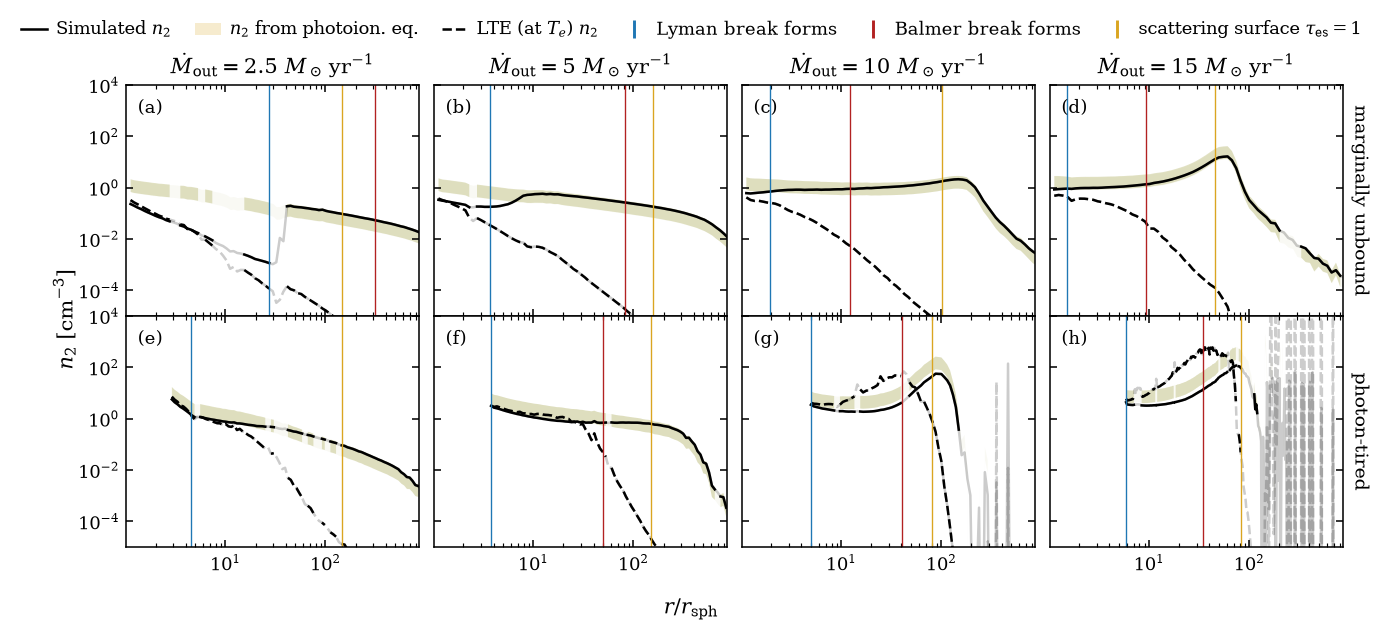

In [4]:
# ===== unified n2 grid, Fig_LRD_gallery style =====
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
FADE=0.20   # opacity multiplier for poorly-converged (converge!=0) cells

def _fade_plot(ax,x,y,good,alpha=1.0,**kw):
    "Line drawn faded everywhere, then re-drawn at full alpha only where converged."
    ax.plot(x,y,alpha=FADE*alpha,**kw)                    # continuous faded underlay
    ax.plot(x,np.where(good,y,np.nan),alpha=alpha,**kw)   # crisp overlay on converged cells

def _fade_fill(ax,x,lo,hi,good,alpha=0.22,**kw):
    ax.fill_between(x,lo,hi,alpha=FADE*alpha,lw=0,**kw)               # faded band everywhere
    ax.fill_between(x,lo,hi,where=good,alpha=alpha,lw=0,**kw)         # full band on converged cells

# row0 = marginally unbound (top), row1 = photon-tired (bottom); columns by Mdot.
# x-axis = r / r_sph(Mdot) from wind_scales.py -- the same normalisation as every other figure.
# Break/photosphere colours match FigOpticalDepth: Lyman = tab:blue, photosphere = goldenrod.
# Poorly-converged (converge!=0) cells are faded to FADE opacity rather than dropped.
layout=[[('m2.5',N2,'mu'),  ('m5',N2,'mu'),  ('m10',N2,'mu'),  ('m15',N2,'mu')],
        [('m2.5',N2PT,'pt'),('m5',N2PT,'pt'),('m10',N2PT,'pt'),('m15',N2PT,'pt')]]
REDD=lambda lab: float(wind_scales.r_sph(float(lab[1:])))   # spherization radius, Mdot-dependent

def _xmax(D):
    xm=2.5*D['rBa'] if np.isfinite(D['rBa']) else 1e17
    return max(xm,1.18*D['rtau1']) if np.isfinite(D.get('rtau1',np.nan)) else xm
xs=[]
for row in layout:
    for cell in row:
        if cell:
            lab,DD,fam=cell; D=DD[lab]; rE=REDD(lab)
            xs+=[D['r'].min()/rE,_xmax(D)/rE]
XLIM=(min(xs)*0.9,max(xs)*1.1)
YLIM=(1e-5,1e4)

fig,AX=plt.subplots(2,4,figsize=(9.5,4.4),sharex=True,sharey=True)
fig.subplots_adjust(left=0.075,right=0.99,top=0.88,bottom=0.13,hspace=0,wspace=0.05)
letters=iter('abcdefgh')
MDOTS = [2.5,5,10,15]
for i,row in enumerate(layout):
    for j,cell in enumerate(row):
        ax=AX[i,j]
        if cell is None:
            ax.axis('off'); continue
        lab,DD,fam=cell; D=DD[lab]; rE=REDD(lab); r=D['r']/rE; good=~D['bad']
        _fade_fill(ax,r,np.maximum(D['n2pred'],1e-30),np.maximum(D['n2pred_hi'],1e-30),good,
                   color='olive',alpha=0.22)
        _fade_plot(ax,r,np.maximum(D['n2act'],1e-30),good,color='black',lw=1.3)
        _fade_plot(ax,r,np.maximum(D['n2lte'],1e-30),good,color='black',ls='--',lw=1.3)
        if np.isfinite(D.get('rtau1',np.nan)): ax.axvline(D['rtau1']/rE,color='goldenrod',ls='-',lw=0.7)
        if np.isfinite(D['rLy']): ax.axvline(D['rLy']/rE,color='tab:blue',ls='-',lw=0.7)
        if np.isfinite(D['rBa']): ax.axvline(D['rBa']/rE,color='firebrick',ls='-',lw=0.7)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.text(0.04,0.94,f'({next(letters)})',transform=ax.transAxes,va='top',ha='left')
        if i == 0:
            ax.set_title(rf'$\dot{{M}}_{{\rm out}} = {MDOTS[j]:g}\ M_\odot\,\mathrm{{yr}}^{{-1}}$', fontsize=11)

AX[0,0].set_xlim(*XLIM); AX[0,0].set_ylim(*YLIM)   # propagates (sharex/sharey)

AX[0,-1].text(1.06,0.5,'marginally unbound',transform=AX[0,-1].transAxes,rotation=270,
        va='center',ha='center',color='k',fontsize=10)
AX[1,-1].text(1.06,0.5,'photon-tired',transform=AX[1,-1].transAxes,rotation=270,
        va='center',ha='center',color='k',fontsize=10)

# one-row legend across the top; break / photosphere keys drawn as VERTICAL bars (cf. FigOpticalDepth)
vbar = lambda c: Line2D([],[],color=c,marker='|',linestyle='None',markersize=9,markeredgewidth=1.5)
leg_handles=[Line2D([],[],color='black',lw=1.3), Patch(facecolor='goldenrod',alpha=0.22),
             Line2D([],[],color='black',ls='--',lw=1.3),
             vbar('tab:blue'), vbar('firebrick'), vbar('goldenrod')]
leg_labels =[r'Simulated $n_2$', r'$n_2$ from photoion. eq.', r'LTE (at $T_e$) $n_2$',
             'Lyman break forms', 'Balmer break forms', r'scattering surface $\tau_{\rm es}=1$']
fig.legend(leg_handles,leg_labels,ncol=6,loc='upper center',bbox_to_anchor=(0.5,1.01),
           frameon=False,fontsize=9,handlelength=1.5,handletextpad=0.5,columnspacing=1.3)

fig.supxlabel(r'$r/r_{\rm sph}$')
fig.supylabel(r'$n_2\ [\mathrm{cm^{-3}}]$')

fig.savefig(os.path.join(FIG_DIR,'FigTemp_n2_grid.pdf'))
fig.savefig(os.path.join(FIG_DIR,'FigTemp_n2_grid.png'),dpi=300)
plt.show()